# Multi qubit circuit

Let us work with two qubit circuit. 

The important two qubit gates are

- CNOT


# Learning Objectives
- Understand tensor product structure of multi-qubit systems
- Construct multi-qubit circuits using Qiskit
- Study entanglement (Bell states)
- Analyze circuits using Statevector and Operator
- Visualize measurement outcomes

In [1]:
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister
from qiskit.quantum_info import Statevector, Operator
import numpy as np
import matplotlib.pyplot as plt

# Multi-Qubit State Representation

A single qubit:

∣ψ⟩=α∣0⟩+β∣1⟩

Two qubits:

∣ψ⟩=α∣00⟩+β∣01⟩+γ∣10⟩+δ∣11⟩

# Multi-Qubit State Representation

In [2]:
# Two-qubit basis states
basis_00 = Statevector.from_label('00')
basis_01 = Statevector.from_label('01')
basis_10 = Statevector.from_label('10')
basis_11 = Statevector.from_label('11')

print(basis_00)

Statevector([1.+0.j, 0.+0.j, 0.+0.j, 0.+0.j],
            dims=(2, 2))


# Tensor Product Concept

In [3]:
# |0> ⊗ |1> = |01>
psi = Statevector.from_label('0').tensor(Statevector.from_label('1'))
print(psi)

Statevector([0.+0.j, 1.+0.j, 0.+0.j, 0.+0.j],
            dims=(2, 2))


# Creating a 2-Qubit Circuit

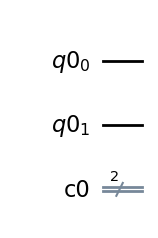

In [4]:
qr = QuantumRegister(2)
cr = ClassicalRegister(2)
qc = QuantumCircuit(qr, cr)

qc.draw('mpl')

# Single-Qubit Gates on Multi-Qubit Systems

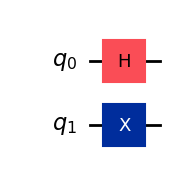

In [5]:
qc = QuantumCircuit(2)

qc.h(0)  # Apply Hadamard to qubit 0
qc.x(1)  # Apply NOT to qubit 1

qc.draw('mpl')

# Controlled Gates (CNOT)

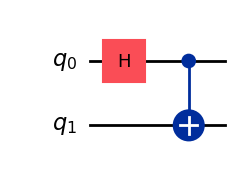

In [6]:
qc = QuantumCircuit(2)

qc.h(0)
qc.cx(0, 1)

qc.draw('mpl')

# Bell State Creation (Entanglement)

∣Φ+⟩= $\frac{1}{\sqrt{2}}$(∣00⟩+∣11⟩)

In [7]:
qc = QuantumCircuit(2)
qc.h(0)
qc.cx(0, 1)

state = Statevector.from_instruction(qc)
print(state)

Statevector([0.70710678+0.j, 0.        +0.j, 0.        +0.j,
             0.70710678+0.j],
            dims=(2, 2))


# Visualizing Statevector

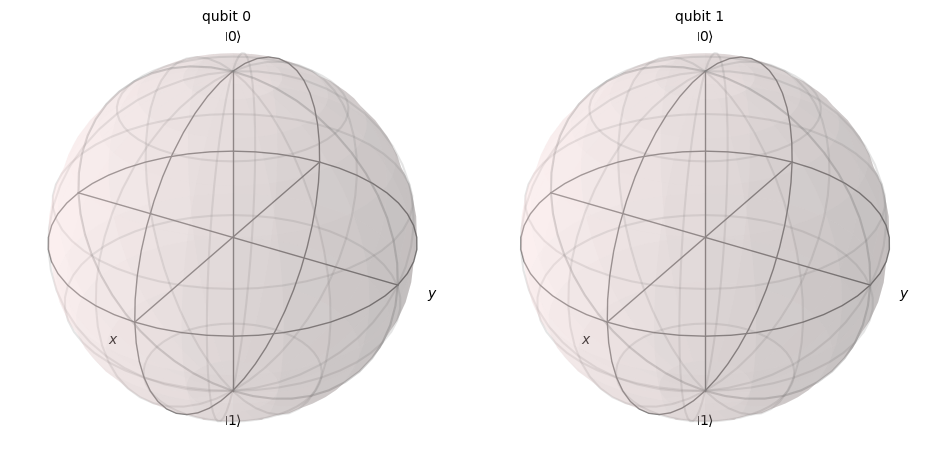

In [8]:
state.draw('bloch')

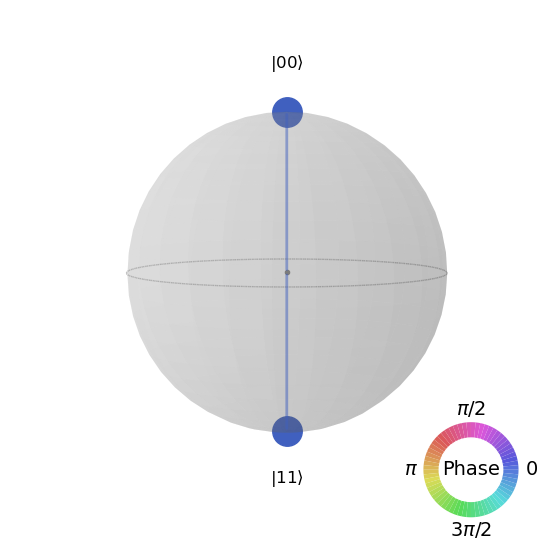

In [9]:
state.draw('qsphere')

# Measurement

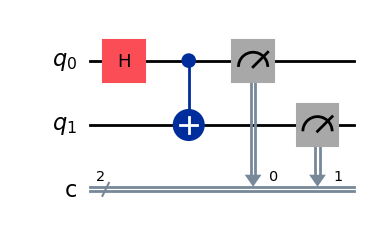

In [10]:
qc = QuantumCircuit(2, 2)
qc.h(0)
qc.cx(0, 1)

qc.measure([0,1], [0,1])
qc.draw('mpl')

# Simulating measurement outcomes

In [11]:
from qiskit_aer import AerSimulator

sim = AerSimulator()
result = sim.run(qc, shots=1024).result()
counts = result.get_counts()

print(counts)

{'11': 496, '00': 528}


# Plot histogram

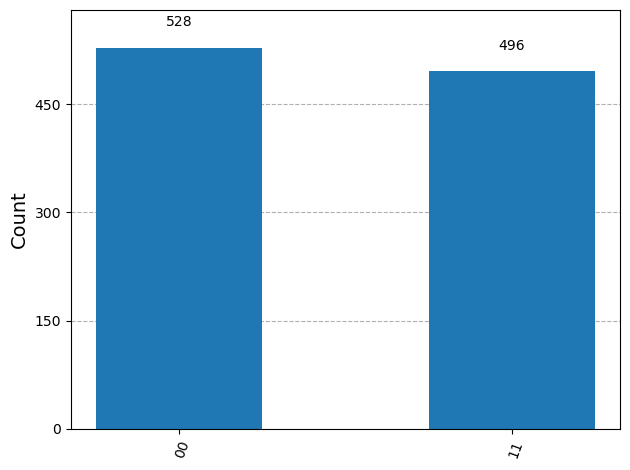

In [12]:
from qiskit.visualization import plot_histogram
plot_histogram(counts)

# Operator representation of data

In [13]:
qc = QuantumCircuit(2)
qc.h(0)
qc.cx(0,1)

U = Operator(qc)
print(U.data)

[[ 0.70710678+0.j  0.70710678+0.j  0.        +0.j  0.        +0.j]
 [ 0.        +0.j  0.        +0.j  0.70710678+0.j -0.70710678+0.j]
 [ 0.        +0.j  0.        +0.j  0.70710678+0.j  0.70710678+0.j]
 [ 0.70710678+0.j -0.70710678+0.j  0.        +0.j  0.        +0.j]]
